In [ ]:
# ============================================
# 🔧 COLAB SETUP + GPU READY
# ============================================

# 1) Upgrade pip & numpy (fixes binary incompatibility)
!pip install --upgrade pip
!pip install --upgrade numpy

# 2) Install GPU-compatible PyTorch + TorchVision + other dependencies
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install timm captum nibabel scikit-learn grad-cam transformers

# 3) Restart runtime after first installation (uncomment if first time)
#import os
#os.kill(os.getpid(), 9)

In [ ]:
# 4) Mount Google Drive
from google.colab import drive
import zipfile, os
drive.mount('/content/drive')

# 5) Extract dataset
zip_path = '/content/drive/MyDrive/Brain Tumor Research/balanced_dataset(1).zip'  # Change path
foldername = os.path.basename(zip_path).split('.')[0].replace(' ', '_').lower() + "_dataset"
os.makedirs(foldername, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(foldername)
print(f"✅ Extracted {zip_path} → {foldername}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted /content/drive/MyDrive/Brain Tumor Research/balanced_dataset(1).zip → balanced_dataset(1)_dataset


In [ ]:
# ============================================
# IMPORTS & GPU CHECK
# ============================================
import random, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import SwinModel
from captum.attr import IntegratedGradients, GradientShap, LayerLRP
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
os.makedirs("XAI_Results", exist_ok=True)


✅ Using device: cuda
GPU Name: Tesla T4
CUDA Version: 12.6


In [ ]:
# ============================================
# DATASET PATHS
# ============================================
dataset_roots = [d for d in os.listdir() if d.endswith('_dataset') and os.path.isdir(d)]
print("Detected dataset roots:", dataset_roots)

def find_split_roots(roots):
    cand = []
    for root in roots:
        for r, dirs, files in os.walk(root):
            base = os.path.basename(r).lower()
            if base in ["train","training","tr"]:
                cand.append(("train", r))
            if base in ["test","val","validation","te","va"]:
                cand.append(("test", r))
    trains = [p for tag,p in cand if tag=="train"]
    tests  = [p for tag,p in cand if tag=="test"]
    if len(trains)==0 or len(tests)==0:
        return None, None
    def score_dir(d):
        try:
            return sum([os.path.isdir(os.path.join(d, x)) for x in os.listdir(d)])
        except:
            return 0
    train_best = max(trains, key=score_dir)
    test_best  = max(tests,  key=score_dir)
    return train_best, test_best

train_dir, test_dir = find_split_roots(dataset_roots)
if (train_dir is None) or (test_dir is None) or (not os.path.isdir(train_dir)) or (not os.path.isdir(test_dir)):
    raise ValueError("Could not find train/test automatically. Set train_dir/test_dir manually.")
print("Train Dir:", train_dir)
print("Test Dir: ", test_dir)

Detected dataset roots: ['balanced_dataset(1)_dataset']
Train Dir: balanced_dataset(1)_dataset/train
Test Dir:  balanced_dataset(1)_dataset/test


In [ ]:
# ============================================
# DATA TRANSFORMS + LOADERS
# ============================================
IMG_SIZE = 224
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Train samples:", len(train_dataset), "Test samples:", len(test_dataset))


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train samples: 30716 Test samples: 7832


In [ ]:
# ============================================
# MODEL DEFINITION
# ============================================
class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return x

class BiLSTMBranch(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)
    def forward(self, x):
        out, _ = self.lstm(x)
        return out[:, -1, :]

class SwinCNNBiLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.swin = SwinModel.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
        for p in self.swin.parameters():
            p.requires_grad = True

        self.cnn = CNNBranch()
        self.lstm = BiLSTMBranch(input_size=768 + 64, hidden_size=128)
        self.fc   = nn.Linear(256, num_classes)
        self.cam_target = self.cnn.conv[3] if len(self.cnn.conv) > 3 else None

    def forward(self, x):
        swin_out = self.swin(pixel_values=x).last_hidden_state
        cnn_vec = self.cnn(x)
        B, T, F = swin_out.shape
        cnn_rep = cnn_vec.unsqueeze(1).expand(B, T, cnn_vec.size(1))
        comb = torch.cat([swin_out, cnn_rep], dim=2)
        lstm_out = self.lstm(comb)
        logits = self.fc(lstm_out)
        return logits

model = SwinCNNBiLSTM(num_classes=num_classes).to(device)
print("Model created successfully.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model created successfully.


In [ ]:
# ============================================
# TRAIN / EVALUATE (WITH AMP)
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
epochs = 10
patience = 3
best_f1 = -1.0
wait = 0

scaler = torch.cuda.amp.GradScaler()  # Mixed precision

# Track metrics
history = {"train_loss": [], "val_acc": [], "val_f1": []}

def evaluate(model, loader, return_probs=False):
    model.eval()
    preds, gts, probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            p = torch.argmax(out, dim=1).cpu().numpy()
            preds.extend(p)
            gts.extend(labels.cpu().numpy())
            if return_probs:
                probs.extend(torch.softmax(out, dim=1).cpu().numpy())
    acc = accuracy_score(gts, preds)
    f1w = f1_score(gts, preds, average='weighted')
    if return_probs:
        return acc, f1w, np.array(gts), np.array(preds), np.array(probs)
    return acc, f1w, np.array(gts), np.array(preds)

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item()
    tr_loss = running / max(1, len(train_loader))
    val_acc, val_f1, y_true, y_pred = evaluate(model, test_loader)
    print(f"Epoch {epoch}/{epochs} | train_loss {tr_loss:.4f} | val_acc {val_acc:.3f} | val_f1 {val_f1:.3f}")

    history["train_loss"].append(tr_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        wait = 0
        torch.save(model.state_dict(), "best_swin_cnn_bilstm.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

# Load best model
model.load_state_dict(torch.load("best_swin_cnn_bilstm.pt", map_location=device))
acc, f1w, y_true, y_pred, y_probs = evaluate(model, test_loader, return_probs=True)
print("\nFinal Test Accuracy:", acc)
print("Final Test F1 (weighted):", f1w)
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))


/tmp/ipython-input-1713291159.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Mixed precision
/tmp/ipython-input-1713291159.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10 | train_loss 0.2449 | val_acc 0.865 | val_f1 0.869


/tmp/ipython-input-1713291159.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10 | train_loss 0.0559 | val_acc 0.731 | val_f1 0.724


/tmp/ipython-input-1713291159.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10 | train_loss 0.0277 | val_acc 0.959 | val_f1 0.959


/tmp/ipython-input-1713291159.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10 | train_loss 0.0183 | val_acc 0.979 | val_f1 0.979


/tmp/ipython-input-1713291159.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10 | train_loss 0.0238 | val_acc 0.959 | val_f1 0.959
Early stopping.

Final Test Accuracy: 0.9899131767109295
Final Test F1 (weighted): 0.9898595489567087
Confusion Matrix:
 [[1958    0    0    0]
 [   0 1958    0    0]
 [  30   47 1879    2]
 [   0    0    0 1958]]
Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      1.00      0.99      1958
  meningioma       0.98      1.00      0.99      1958
    no_tumor       1.00      0.96      0.98      1958
   pituitary       1.00      1.00      1.00      1958

    accuracy                           0.99      7832
   macro avg       0.99      0.99      0.99      7832
weighted avg       0.99      0.99      0.99      7832



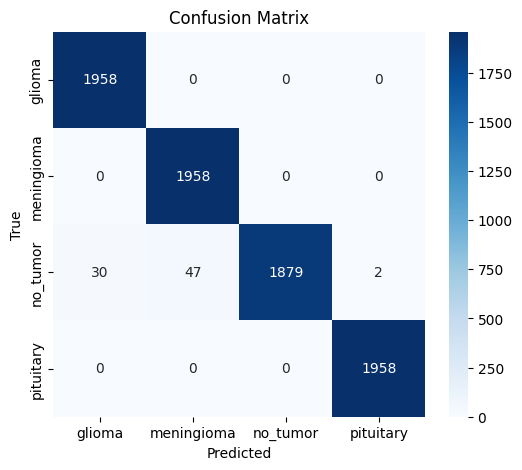

In [ ]:
# ============================================
# 📊 CONFUSION MATRIX PLOT
# ============================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("XAI_Results/confusion_matrix.png")
plt.show()


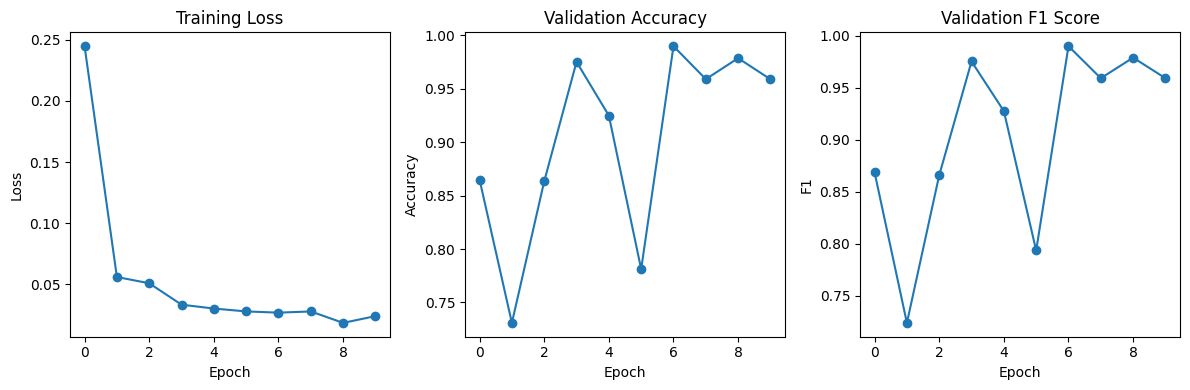

In [ ]:
# ============================================
# 📈 TRAINING CURVES
# ============================================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history["train_loss"], marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,3,2)
plt.plot(history["val_acc"], marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1,3,3)
plt.plot(history["val_f1"], marker='o')
plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")

plt.tight_layout()
plt.savefig("XAI_Results/training_curves.png")
plt.show()


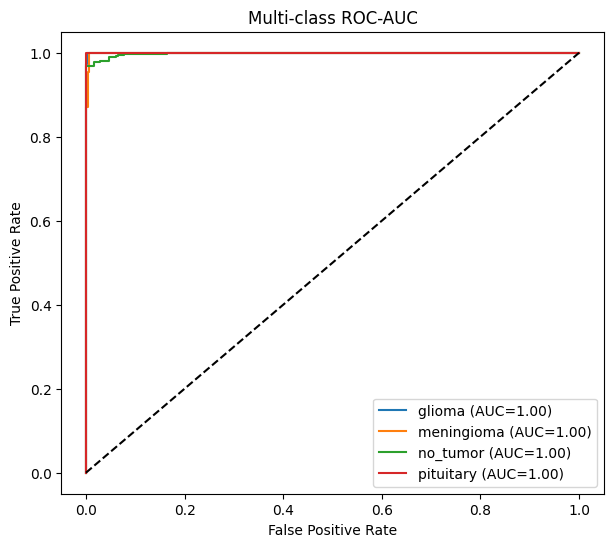

In [ ]:
# ============================================
# 📉 ROC-AUC Curves
# ============================================
try:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    fpr, tpr, roc_auc = {}, {}, {}
    plt.figure(figsize=(7,6))
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC-AUC")
    plt.legend()
    plt.savefig("XAI_Results/roc_auc.png")
    plt.show()
except Exception as e:
    print("ROC-AUC error:", e)


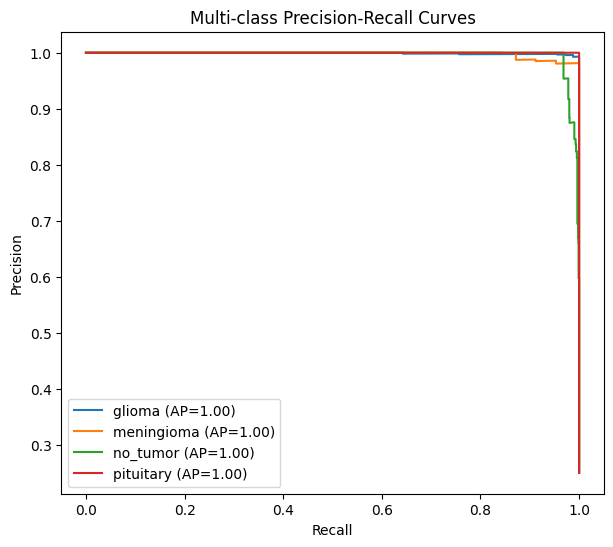

In [ ]:
# ============================================
# 📉 Precision-Recall (PR) Curves
# ============================================
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    precision, recall, pr_auc = {}, {}, {}
    plt.figure(figsize=(7,6))
    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        pr_auc[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall[i], precision[i], label=f"{class_names[i]} (AP={pr_auc[i]:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Multi-class Precision-Recall Curves")
    plt.legend()
    plt.savefig("XAI_Results/pr_curve.png")
    plt.show()
except Exception as e:
    print("PR curve error:", e)

In [ ]:
# ============================================
# XAI: IG, GradientShap, LRP, Grad-CAM
# ============================================
model.eval()
ig = IntegratedGradients(model)
gs = GradientShap(model)

IMN_MEAN = np.array([0.485,0.456,0.406])
IMN_STD  = np.array([0.229,0.224,0.225])

def tensor_to_img01(t):
    x = t.detach().cpu().permute(1,2,0).numpy()
    x = (x * IMN_STD) + IMN_MEAN
    x = np.clip(x, 0, 1)
    return x

x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
x_sample = x_batch[:1]
y_sample = y_batch[:1]


In [ ]:
# IG
try:
    model.train()
    ig_attr = ig.attribute(inputs=x_sample, target=int(y_sample[0]), n_steps=24)
    model.eval()
    ig_map = ig_attr[0].mean(dim=0).detach().cpu().numpy()
    plt.imshow(ig_map, cmap='hot'); plt.title("IG"); plt.colorbar()
    plt.savefig("XAI_Results/IG.png"); plt.close()
    print("Saved IG -> XAI_Results/IG.png")
except Exception as e:
    print("IG error:", e)


Saved IG -> XAI_Results/IG.png


In [ ]:
# GradientShap
try:
    model.train()
    baseline = torch.zeros_like(x_sample).to(device)
    gs_attr = gs.attribute(inputs=x_sample, baselines=baseline, target=int(y_sample[0]), n_samples=16)
    model.eval()
    gs_map = gs_attr[0].mean(dim=0).detach().cpu().numpy()
    plt.imshow(gs_map, cmap='cool'); plt.title("GradientShap"); plt.colorbar()
    plt.savefig("XAI_Results/GradientShap.png"); plt.close()
    print("Saved GradientShap -> XAI_Results/GradientShap.png")
except Exception as e:
    print("GradientShap error:", e)


Saved GradientShap -> XAI_Results/GradientShap.png


In [ ]:
# LRP
try:
    target_layer = model.cam_target
    if target_layer is not None:
        lrp = LayerLRP(model, target_layer)
        lrp_attr = lrp.attribute(inputs=x_sample, target=int(y_sample[0]))
        lrp_map = lrp_attr[0].mean(dim=0).detach().cpu().numpy()
        plt.imshow(lrp_map, cmap='seismic'); plt.title("LRP"); plt.colorbar()
        plt.savefig("XAI_Results/LRP.png"); plt.close()
        print("Saved LRP -> XAI_Results/LRP.png")
except Exception as e:
    print("LRP error:", e)


LRP error: Module of type <class 'torch.nn.modules.normalization.LayerNorm'> has no rule defined and nodefault rule exists for this module type. Please, set a ruleexplicitly for this module and assure that it is appropriatefor this type of layer.


In [ ]:
# Grad-CAM
try:
    if model.cam_target is not None:
        target_layers = [model.cam_target]
        cam = GradCAM(model=model, target_layers=target_layers)  # no use_cuda
        targets = [ClassifierOutputTarget(int(y_sample[0]))]
        grayscale_cam = cam(input_tensor=x_sample, targets=targets)[0]
        img_np = tensor_to_img01(x_sample[0])
        cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        plt.imshow(cam_img); plt.axis('off')
        plt.savefig("XAI_Results/GradCAM.png"); plt.close()
        print("Saved Grad-CAM -> XAI_Results/GradCAM.png")
except Exception as e:
    print("Grad-CAM error:", e)

print("✅ XAI outputs saved to ./XAI_Results")
print("✅ Model saved at best_swin_cnn_bilstm.pt")

Grad-CAM error: cudnn RNN backward can only be called in training mode
✅ XAI outputs saved to ./XAI_Results
✅ Model saved at best_swin_cnn_bilstm.pt
